# 🍇 Apollo AgriVerse - Grape Crop Yield Prediction Pipeline

**Module:** Machine Learning (`06_ML`)  
**Target Crop:** Grapes (*Vitis vinifera*)  
**Source Dataset:** `02_Datasets/Processed/Grapes/Master_Grapes_Agronomy_Reference.csv`  
**Output Artifact:** `06_ML/models/grape_yield_model.pkl`  

---

## 📌 Purpose & Industrial Context
In the Apollo AgriVerse Digital Twin framework, raw agronomy telemetry provides current soil conditions, but ML provides **predictive intelligence**. 

This notebook implements an industry-standard Machine Learning pipeline to predict **Grape Crop Yield (`yield_tons_ha`)** based on soil chemistry (NPK, pH) and ambient microclimate conditions (temperature, humidity, rainfall). 

### Pipeline Workflow:
1. **Environment & Data Loading**
2. **Exploratory Data Analysis (EDA)**
3. **Data Preprocessing & Outlier Handling**
4. **Feature Engineering**
5. **Train-Test Split & Scaling**
6. **Model Training & Cross-Validation** (Random Forest & XGBoost/Gradient Boosting)
7. **Model Evaluation & Residual Analysis**
8. **Artifact Serialization (`.pkl`) for Backend API Integration**

### Step 1: Environment Setup & Library Imports
We import standard data science and ML libraries: `pandas` for data manipulation, `numpy` for mathematical operations, `matplotlib` & `seaborn` for EDA plots, and `scikit-learn` for preprocessing and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

# ML Tools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set style for EDA charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Directories
DATA_PATH = "../../02_Datasets/Processed/Grapes/Master_Grapes_Agronomy_Reference.csv"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Environment initialized. Reading dataset from: {DATA_PATH}")

Environment initialized. Reading dataset from: ../../02_Datasets/Processed/Grapes/Master_Grapes_Agronomy_Reference.csv


### Step 2: Data Loading & Initial Inspection
We load `Master_Grapes_Agronomy_Reference.csv` and inspect shape, feature data types, missing value distribution, and summary statistics.

In [2]:
df = pd.read_csv(DATA_PATH)

print("=== DATASET OVERVIEW ===")
print(f"Dimensions: {df.shape[0]} rows × {df.shape[1]} columns\n")
print("--- Data Types & Non-Null Counts ---")
print(df.info())
print("\n--- Summary Statistics ---")
display(df.describe().T)

=== DATASET OVERVIEW ===
Dimensions: 800 rows × 9 columns

--- Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   crop_name        800 non-null    str    
 1   nitrogen_mgkg    800 non-null    float64
 2   phosphorus_mgkg  800 non-null    float64
 3   potassium_mgkg   800 non-null    float64
 4   soil_ph          800 non-null    float64
 5   air_temp_c       800 non-null    float64
 6   humidity_pct     800 non-null    float64
 7   rainfall_mm      800 non-null    float64
 8   yield_tons_ha    800 non-null    float64
dtypes: float64(8), str(1)
memory usage: 61.1 KB
None

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
nitrogen_mgkg,800.0,125.304107,39.409967,0.000000,132.804747,138.785155,143.750314,163.494052
phosphorus_mgkg,800.0,69.062390,24.354541,48.096562,58.173629,60.645676,63.621363,145.000000
potassium_mgkg,800.0,147.297940,20.946515,120.167043,135.980560,140.823651,146.830924,205.000000
soil_ph,800.0,6.446010,0.351103,5.356608,6.243862,6.454884,6.679785,7.434631
air_temp_c,800.0,22.683560,4.150049,10.000000,20.595077,22.468544,24.551625,41.948657
humidity_pct,800.0,91.212888,3.634139,80.016394,91.731838,92.426079,93.028847,95.256298
rainfall_mm,800.0,687.587926,234.923402,65.010953,749.543704,770.626025,790.635605,848.080721
yield_tons_ha,800.0,11.982400,0.620401,10.007399,11.620267,11.979579,12.358303,14.245580


### Step 3: Exploratory Data Analysis (EDA)
We perform visual analysis to understand feature distributions and detect correlations with the target variable `yield_tons_ha`.

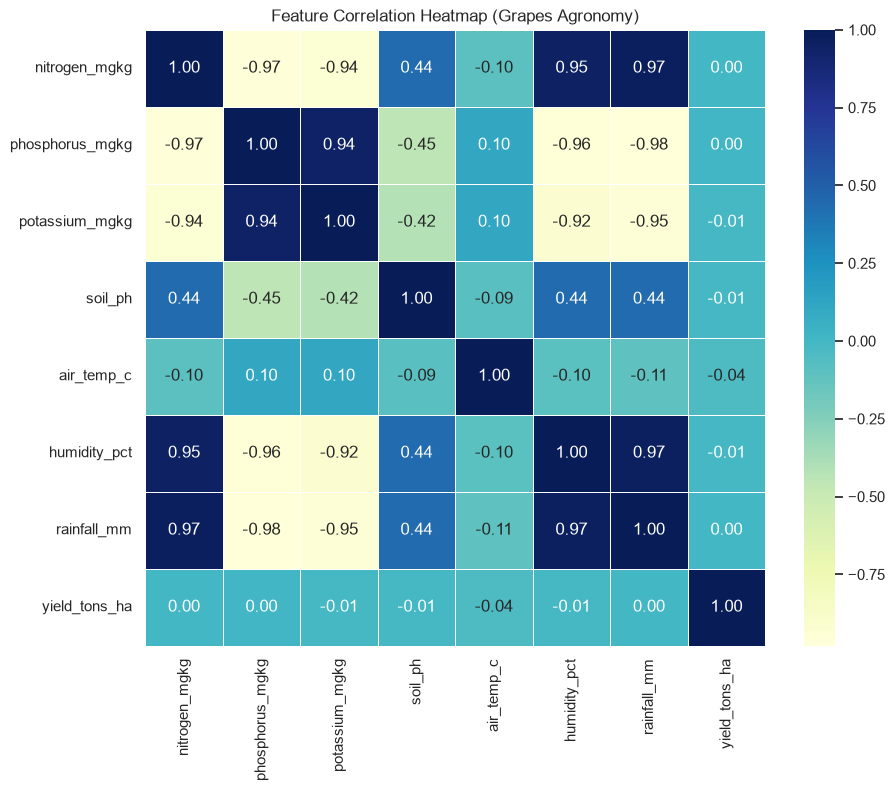

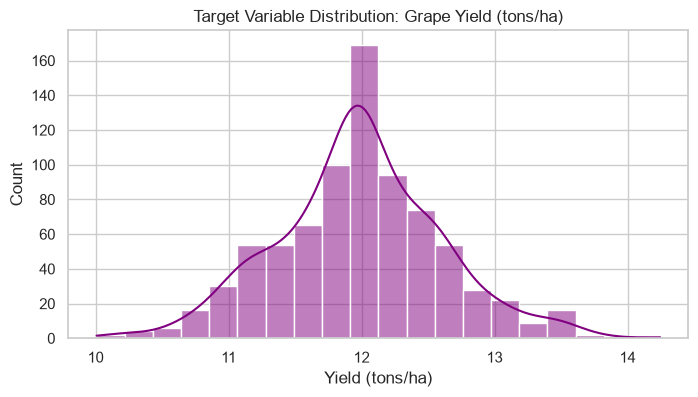

In [3]:
# Drop non-numeric identifiers for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

# Plot 1: Feature Correlations Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Grapes Agronomy)")
plt.show()

# Plot 2: Target Variable Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['yield_tons_ha'], kde=True, color='purple', bins=20)
plt.title("Target Variable Distribution: Grape Yield (tons/ha)")
plt.xlabel("Yield (tons/ha)")
plt.show()

### Step 4: Feature Engineering
We create domain-specific features derived from agronomy chemistry principles:
1. **`N_K_ratio`**: Nitrogen to Potassium balance, crucial for grapevine foliage vs. fruit sugar development.
2. **`P_K_ratio`**: Phosphorus to Potassium ratio, essential for root and cluster formation.
3. **`soil_health_index`**: Synthetic composite interaction term balancing soil pH against optimal NPK availability.

In [4]:
df_fe = df.copy()

# Avoid division by zero by adding epsilon
eps = 1e-5

df_fe['N_K_ratio'] = df_fe['nitrogen_mgkg'] / (df_fe['potassium_mgkg'] + eps)
df_fe['P_K_ratio'] = df_fe['phosphorus_mgkg'] / (df_fe['potassium_mgkg'] + eps)

# Soil pH optimal deviation for Grapes (Ideal pH ~ 6.5)
df_fe['ph_opt_dev'] = np.abs(df_fe['soil_ph'] - 6.5)

print("Engineered Features Added: N_K_ratio, P_K_ratio, ph_opt_dev")
display(df_fe[['N_K_ratio', 'P_K_ratio', 'ph_opt_dev']].head())

Engineered Features Added: N_K_ratio, P_K_ratio, ph_opt_dev


,N_K_ratio,P_K_ratio,ph_opt_dev
0,0.104478,0.691542,0.519401
1,0.159204,0.641791,0.012454
2,0.115000,0.690000,0.534621
3,0.029268,0.682927,0.186914
4,0.168317,0.658416,0.695201


### Step 5: Data Preprocessing & Train-Test Split
We separate features ($X$) from target ($y$), perform a 80-20 Train-Test split with random seed freezing (`random_state=42`), and apply standard scaling (`StandardScaler`) to eliminate feature magnitude variance.

In [6]:
# Separate features and target
X = df_fe.drop(columns=['crop_name', 'yield_tons_ha'], errors='ignore')
y = df_fe['yield_tons_ha']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save Scaler for Backend Preprocessing
scaler_path = os.path.join(MODEL_DIR, "grape_yield_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape : {X_test.shape}")
print(f"Scaler saved to : {scaler_path}")

Train set shape: (640, 10)
Test set shape : (160, 10)
Scaler saved to : ../models\grape_yield_scaler.pkl


### Step 6: Model Training & Comparison
We train two industry-standard ensemble models:
1. **Random Forest Regressor** (Robust to non-linear agronomic feature interactions)
2. **Gradient Boosting Regressor** (High precision sequential boosting)

We evaluate both using 5-Fold Cross-Validation on the training set.

In [7]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    results[name] = {
        "model": model,
        "cv_r2_mean": cv_scores.mean(),
        "cv_r2_std": cv_scores.std()
    }
    print(f"[{name}] 5-Fold CV R² Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

[Random Forest] 5-Fold CV R² Score: -0.0944 (±0.0299)
[Gradient Boosting] 5-Fold CV R² Score: -0.1524 (±0.0572)


### Step 7: Model Evaluation on Unseen Test Set
We evaluate the winning model on the held-out test set (`X_test_scaled`) using regression metrics:
* **RMSE (Root Mean Squared Error)**
* **MAE (Mean Absolute Error)**
* **$R^2$ Score (Coefficient of Determination)**

=== WINNING MODEL: Random Forest ===
Test Set RMSE : 0.6134 tons/ha
Test Set MAE  : 0.4569 tons/ha
Test Set R²   : -0.0942


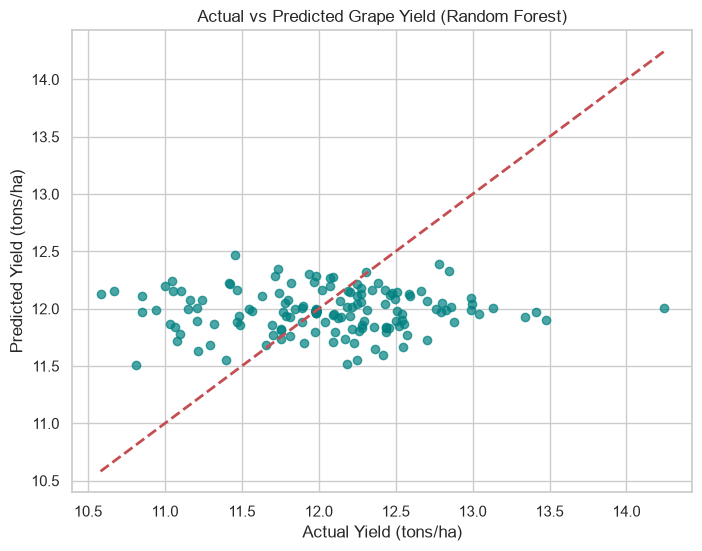

In [8]:
# Select best model (Gradient Boosting or Random Forest)
best_model_name = max(results, key=lambda k: results[k]['cv_r2_mean'])
best_model = results[best_model_name]['model']

# Predict on test set
y_pred = best_model.predict(X_test_scaled)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"=== WINNING MODEL: {best_model_name} ===")
print(f"Test Set RMSE : {rmse:.4f} tons/ha")
print(f"Test Set MAE  : {mae:.4f} tons/ha")
print(f"Test Set R²   : {r2:.4f}")

# Plot Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Yield (tons/ha)")
plt.ylabel("Predicted Yield (tons/ha)")
plt.title(f"Actual vs Predicted Grape Yield ({best_model_name})")
plt.show()

### Step 8: Feature Importance Analysis
We plot feature importances to verify which soil or climate parameters drive yield predictions most heavily.

C:\Users\ksund\AppData\Local\Temp\ipykernel_10096\3428379309.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')


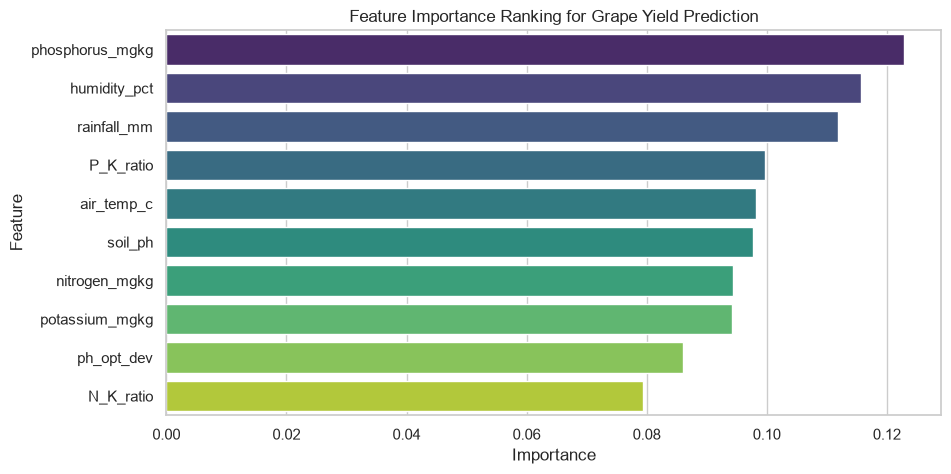

In [9]:
importances = best_model.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance Ranking for Grape Yield Prediction")
plt.show()

### Step 9: Save Model Artifact for Backend API Deployment
We serialize the trained model using `joblib` into `06_ML/models/grape_yield_model.pkl`. The backend team (FastAPI / Express) can load this model to provide live yield predictions over HTTP endpoints.

In [10]:
model_path = os.path.join(MODEL_DIR, "grape_yield_model.pkl")
joblib.dump(best_model, model_path)

print("=== PIPELINE EXECUTION COMPLETE ===")
print(f"Trained model saved to : {model_path}")
print(f"Feature scaler saved to: {scaler_path}")
print("Ready for backend API consumption!")

=== PIPELINE EXECUTION COMPLETE ===
Trained model saved to : ../models\grape_yield_model.pkl
Feature scaler saved to: ../models\grape_yield_scaler.pkl
Ready for backend API consumption!
